Starfish Uniformization - Local Basis
Local: 60 Wendland C2, epsilon=0.3
Min support: 10 pts
Reselect centers every: 800 steps
Initial density std/mean: 0.596517
Generated 60 uniform centers on surface
Computing uniform reference values...
Done.

Main iteration (Euler Forward)
Step 0: density std/mean = 0.596010, max|b| = 5.215927e-01, v_max = 270.4415, active basis = 60/60
Step 200: density std/mean = 0.661706, max|b| = 4.931427e-01, v_max = 36.5266, active basis = 60/60
Step 400: density std/mean = 0.699215, max|b| = 3.996527e-01, v_max = 12.0619, active basis = 60/60
Step 600: density std/mean = 0.523536, max|b| = 1.994570e-01, v_max = 2.6946, active basis = 60/60

Step 800: Reselecting basis centers...
  New centers generated, reference values recomputed
Step 800: density std/mean = 0.358858, max|b| = 5.533258e-03, v_max = 0.9973, active basis = 60/60
Step 1000: density std/mean = 0.371602, max|b| = 9.740685e-05, v_max = 0.0094, active basis = 60/60
Step 1200: density std/mean = 0.

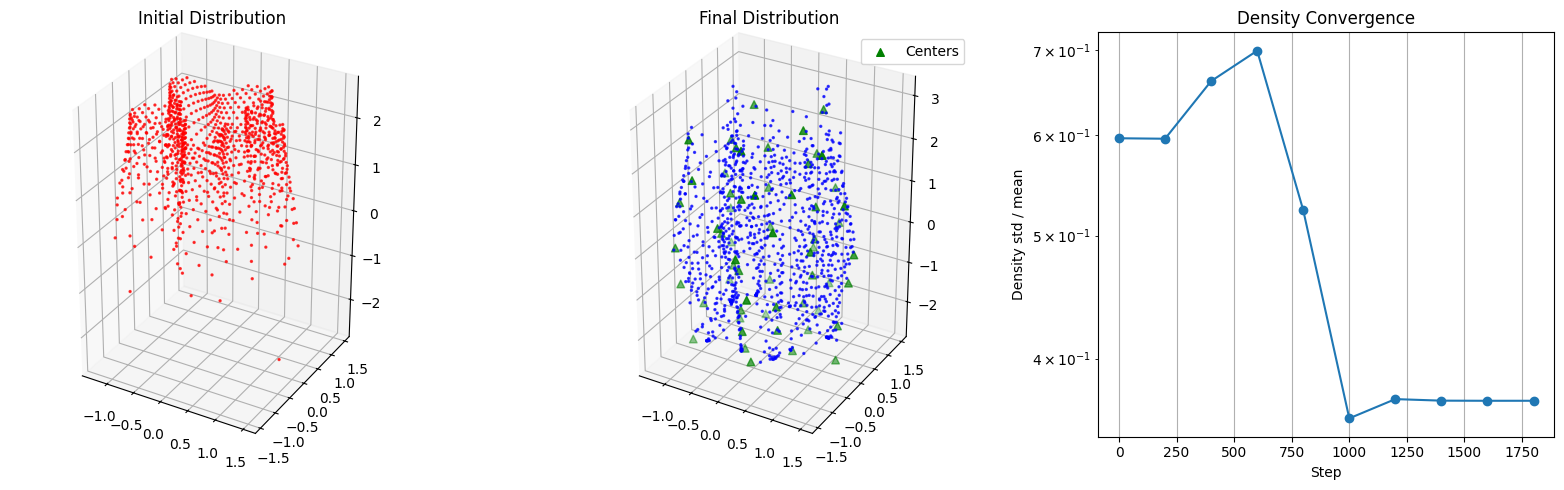

In [10]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 1000
N_LOCAL = 60
EPSILON = 0.3
ALPHA = 2.0
DT = 0.01
MAX_STEPS = 1600
TOL = 1e-10
PROJECT_EVERY_STEP = True
K_NEIGHBORS = 20
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6
RESELECT_INTERVAL = 800

# 海星形曲面参数
NUM_ARMS = 5
ARM_AMPLITUDE = 0.4
Z_MIN, Z_MAX = -2.5, 2.5

def r_of_z_theta(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    return base_r * star_modulation

def r_and_dr(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    d_base_dz = -0.1 * np.pi / (Z_MAX - Z_MIN) * 2 * np.sin(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    d_star_dtheta = -ARM_AMPLITUDE * NUM_ARMS * np.sin(NUM_ARMS * theta)
    r = base_r * star_modulation
    dr_dz = d_base_dz * star_modulation
    dr_dtheta = base_r * d_star_dtheta
    return r, dr_dz, dr_dtheta

# ============================================
# 1. 海星曲面几何工具
# ============================================
def starfish_normal(X):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    r_xy = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    r, drdz, drdt = r_and_dr(z, theta)
    cos_t = x / (r_xy + 1e-15)
    sin_t = y / (r_xy + 1e-15)
    tx = drdz * cos_t
    ty = drdz * sin_t
    tz = np.ones_like(z)
    ux = drdt * cos_t - r * sin_t
    uy = drdt * sin_t + r * cos_t
    uz = np.zeros_like(z)
    nx = ty * uz - tz * uy
    ny = tz * ux - tx * uz
    nz = tx * uy - ty * ux
    normal = np.column_stack([nx, ny, nz])
    return normal / (np.linalg.norm(normal, axis=1, keepdims=True) + 1e-15)

def project_to_starfish(X, max_iter=30, tol=1e-12):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        r_current = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        r_target, _, _ = r_and_dr(z, theta)
        X_new = np.zeros_like(X)
        X_new[:, 0] = r_target * x / (r_current + 1e-15)
        X_new[:, 1] = r_target * y / (r_current + 1e-15)
        X_new[:, 2] = z
        X = X_new
    return X

def tangent_projection(v, X):
    normals = starfish_normal(X)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================
# 2. 生成初始点云
# ============================================
def fibonacci_starfish(n, concentration=0.2):
    indices = np.arange(n)
    z_uniform = Z_MIN + (Z_MAX - Z_MIN) * indices / n
    z_shifted = (z_uniform - Z_MIN) / (Z_MAX - Z_MIN)
    z_compressed = z_shifted ** concentration
    z = Z_MIN + z_compressed * (Z_MAX - Z_MIN)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    r, _, _ = r_and_dr(z, theta)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y, z])

# ============================================
# 3. Wendland C2 局部基函数
# ============================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

def local_basis_gradients_tangent(X, centers, epsilon):
    normals = starfish_normal(X)
    grads_3d = local_basis_gradients(X, centers, epsilon)
    normal_proj = np.sum(grads_3d * normals[:, np.newaxis, :], axis=2)
    return grads_3d - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================
# 4. 生成均匀基函数中心
# ============================================
def generate_uniform_points(n):
    z_vals = np.linspace(Z_MIN, Z_MAX, 1000)
    theta_sample = np.linspace(0, 2*np.pi, 500)
    ZZ, TT = np.meshgrid(z_vals, theta_sample, indexing='ij')
    r_grid, drdz_grid, drdt_grid = r_and_dr(ZZ, TT)
    area_element = r_grid * np.sqrt(r_grid**2 + drdt_grid**2 + r_grid**2 * drdz_grid**2)
    marginal_area = np.sum(area_element, axis=1) * (2*np.pi / 500)
    cdf = np.cumsum(marginal_area)
    cdf = cdf / cdf[-1]
    z_sampled = np.interp(np.random.rand(n), cdf, z_vals)
    theta_sampled = np.zeros(n)
    for i in range(n):
        z_idx = np.searchsorted(z_vals, z_sampled[i])
        if z_idx >= len(z_vals): z_idx = len(z_vals) - 1
        theta_dist = r_grid[z_idx, :] * np.sqrt(r_grid[z_idx, :]**2 + drdt_grid[z_idx, :]**2 + r_grid[z_idx, :]**2 * drdz_grid[z_idx, :]**2)
        theta_cdf = np.cumsum(theta_dist)
        theta_cdf = theta_cdf / theta_cdf[-1]
        theta_sampled[i] = np.interp(np.random.rand(), theta_cdf, theta_sample)
    r_sampled, _, _ = r_and_dr(z_sampled, theta_sampled)
    x = r_sampled * np.cos(theta_sampled)
    y = r_sampled * np.sin(theta_sampled)
    return np.column_stack([x, y, z_sampled])

def generate_uniform_centers(n_centers):
    candidates = generate_uniform_points(5000)
    selected = [np.random.randint(len(candidates))]
    min_dist = np.full(len(candidates), np.inf)
    for _ in range(n_centers - 1):
        last = candidates[selected[-1]]
        dist_to_last = np.linalg.norm(candidates - last, axis=1)
        min_dist = np.minimum(min_dist, dist_to_last)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)
        min_dist[next_idx] = -1
    return candidates[np.array(selected)]

# ============================================
# 5. 均匀参考值
# ============================================
def compute_uniform_reference(centers, epsilon, n_samples=20000):
    X_ref = generate_uniform_points(n_samples)
    
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, 21)[1:21]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = local_basis_values(X_ref, centers, epsilon)
    return np.average(psi_sample, weights=areas, axis=0)

# ============================================
# 6. 密度估计
# ============================================
def estimate_density_std(X, k_neighbors=K_NEIGHBORS):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================
# 7. 支撑修剪求解器
# ============================================
def solve_with_support_pruning(X, centers, epsilon, uniform_avg, alpha,
                               min_support=5, support_threshold=1e-8):
    M_total = len(centers)
    
    psi = local_basis_values(X, centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    valid_mask = support_counts >= min_support
    
    if np.sum(valid_mask) == 0:
        return np.zeros_like(X), np.zeros(M_total), valid_mask, support_counts
    
    psi_grad_full = local_basis_gradients_tangent(X, centers, epsilon)
    psi_valid = psi[:, valid_mask]
    psi_grad_valid = psi_grad_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = -alpha * (np.mean(psi_valid, axis=0) - uniform_avg[valid_mask])
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X)
    
    return vT, c, valid_mask, support_counts

# ============================================
# 8. 主算法
# ============================================
def main():
    print("=" * 60)
    print("Starfish Uniformization - Local Basis")
    print(f"Local: {N_LOCAL} Wendland C2, epsilon={EPSILON}")
    print(f"Min support: {MIN_SUPPORT} pts")
    print(f"Reselect centers every: {RESELECT_INTERVAL} steps")
    print("=" * 60)
    
    X = fibonacci_starfish(N, concentration=0.2)
    X_initial = X.copy()
    
    density_std_initial = estimate_density_std(X)
    print(f"Initial density std/mean: {density_std_initial:.6f}")
    
    np.random.seed(42)
    centers = generate_uniform_centers(N_LOCAL)
    print(f"Generated {N_LOCAL} uniform centers on surface")
    
    print("Computing uniform reference values...")
    uniform_avg = compute_uniform_reference(centers, EPSILON, n_samples=20000)
    print("Done.\n")
    
    density_history = [density_std_initial]
    
    print("=" * 60)
    print("Main iteration (Euler Forward)")
    print("=" * 60)
    
    for step in range(MAX_STEPS):
        if step > 0 and step % RESELECT_INTERVAL == 0:
            print(f"\nStep {step}: Reselecting basis centers...")
            centers = generate_uniform_centers(N_LOCAL)
            uniform_avg = compute_uniform_reference(centers, EPSILON, n_samples=20000)
            print(f"  New centers generated, reference values recomputed")
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, centers, EPSILON, uniform_avg, ALPHA,
            min_support=MIN_SUPPORT,
            support_threshold=SUPPORT_THRESHOLD
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        if PROJECT_EVERY_STEP:
            X = project_to_starfish(X)
        
        if step % 200 == 0:
            psi = local_basis_values(X, centers, EPSILON)
            b_full = -ALPHA * (np.mean(psi, axis=0) - uniform_avg)
            max_b = np.max(np.abs(b_full))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            
            n_active = np.sum(valid_mask)
            
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max|b| = {max_b:.6e}, v_max = {v_norm:.4f}, "
                  f"active basis = {n_active}/{N_LOCAL}")
        
        if v_norm < 1e-15:
            print(f"\nVelocity converged at step {step}")
            break
    
    density_std_final = estimate_density_std(X)
    density_history.append(density_std_final)
    print(f"\nFinal density std/mean: {density_std_final:.6f}")
    
    # 可视化
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=2, c='red', alpha=0.7)
    ax1.set_title('Initial Distribution')
    ax1.set_box_aspect([1, 1, 1.5])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax2.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=30, c='green', marker='^', label='Centers')
    ax2.set_title('Final Distribution')
    ax2.set_box_aspect([1, 1, 1.5])
    ax2.legend()
    
    ax3 = fig.add_subplot(133)
    ax3.semilogy(np.arange(0, len(density_history)) * 200, density_history, 'o-')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Density std / mean')
    ax3.set_title('Density Convergence')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return X, density_history

if __name__ == "__main__":
    X_final, density_hist = main()

Starfish Uniformization - Mixed Basis
Polynomial: deg≤3, 19 functions
Local: 30 Wendland C2, epsilon=0.4
Total: 49 basis functions
Min support: 10 pts
Reselect centers every: 800 steps
Initial density std/mean: 0.596517
Generated 30 uniform centers on surface
Computing uniform reference values...
Done.

Main iteration (Euler Forward)
Step 0: density std/mean = 0.596165, max|b| = 1.341309e+01, v_max = 242.2090, active basis = 49/49 (local=30/30)
Step 200: density std/mean = 0.626853, max|b| = 1.270490e+01, v_max = 34.6799, active basis = 49/49 (local=30/30)
Step 400: density std/mean = 0.658543, max|b| = 9.568338e+00, v_max = 7.7135, active basis = 49/49 (local=30/30)
Step 600: density std/mean = 0.306667, max|b| = 2.749773e+00, v_max = 1.2581, active basis = 49/49 (local=30/30)

Step 800: Reselecting basis centers...
  New centers generated, reference values recomputed
Step 800: density std/mean = 0.158659, max|b| = 1.388964e-02, v_max = 0.1631, active basis = 49/49 (local=30/30)
Step 

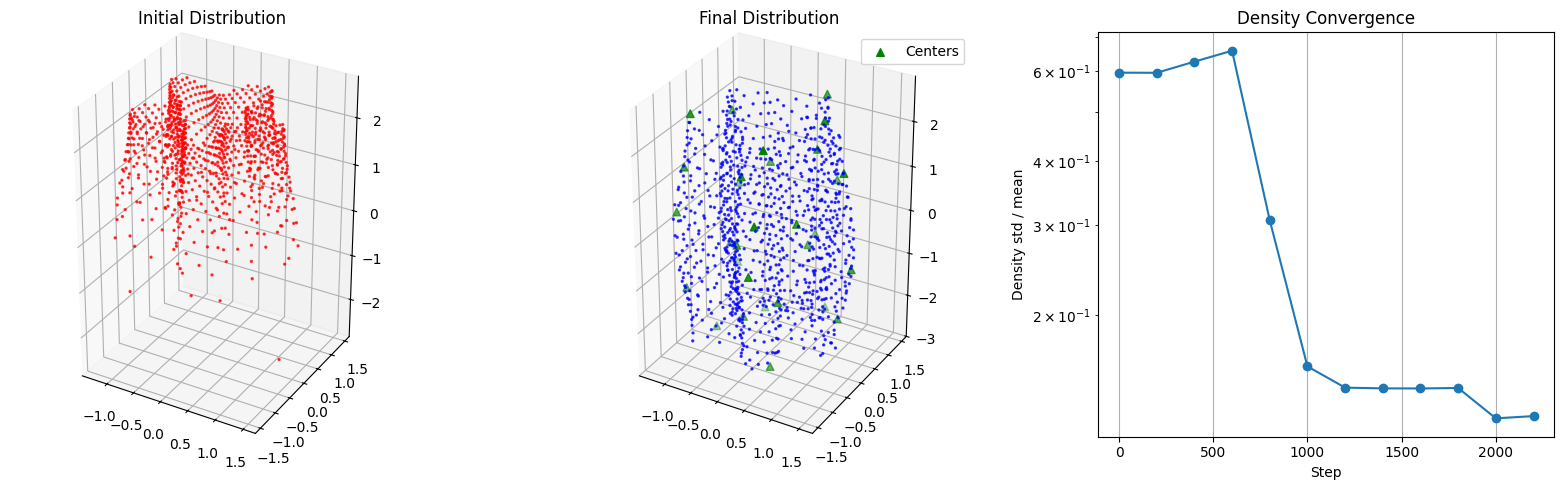

In [9]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 1000
MAX_DEG = 3
N_LOCAL = 30
EPSILON = 0.4
ALPHA = 2.0
DT = 0.01
MAX_STEPS = 2000
TOL = 1e-10
PROJECT_EVERY_STEP = True
K_NEIGHBORS = 20
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6
RESELECT_INTERVAL = 800

# 海星形曲面参数
NUM_ARMS = 5
ARM_AMPLITUDE = 0.4
Z_MIN, Z_MAX = -2.5, 2.5

def r_of_z_theta(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    return base_r * star_modulation

def r_and_dr(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    d_base_dz = -0.1 * np.pi / (Z_MAX - Z_MIN) * 2 * np.sin(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    d_star_dtheta = -ARM_AMPLITUDE * NUM_ARMS * np.sin(NUM_ARMS * theta)
    r = base_r * star_modulation
    dr_dz = d_base_dz * star_modulation
    dr_dtheta = base_r * d_star_dtheta
    return r, dr_dz, dr_dtheta

# ============================================
# 1. 海星曲面几何工具
# ============================================
def starfish_normal(X):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    r_xy = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    r, drdz, drdt = r_and_dr(z, theta)
    cos_t = x / (r_xy + 1e-15)
    sin_t = y / (r_xy + 1e-15)
    tx = drdz * cos_t
    ty = drdz * sin_t
    tz = np.ones_like(z)
    ux = drdt * cos_t - r * sin_t
    uy = drdt * sin_t + r * cos_t
    uz = np.zeros_like(z)
    nx = ty * uz - tz * uy
    ny = tz * ux - tx * uz
    nz = tx * uy - ty * ux
    normal = np.column_stack([nx, ny, nz])
    return normal / (np.linalg.norm(normal, axis=1, keepdims=True) + 1e-15)

def project_to_starfish(X, max_iter=30, tol=1e-12):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        r_current = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        r_target, _, _ = r_and_dr(z, theta)
        X_new = np.zeros_like(X)
        X_new[:, 0] = r_target * x / (r_current + 1e-15)
        X_new[:, 1] = r_target * y / (r_current + 1e-15)
        X_new[:, 2] = z
        X = X_new
    return X

def tangent_projection(v, X):
    normals = starfish_normal(X)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================
# 2. 生成初始点云
# ============================================
def fibonacci_starfish(n, concentration=0.2):
    indices = np.arange(n)
    z_uniform = Z_MIN + (Z_MAX - Z_MIN) * indices / n
    z_shifted = (z_uniform - Z_MIN) / (Z_MAX - Z_MIN)
    z_compressed = z_shifted ** concentration
    z = Z_MIN + z_compressed * (Z_MAX - Z_MIN)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    r, _, _ = r_and_dr(z, theta)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y, z])

# ============================================
# 3. 多项式基函数
# ============================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return np.column_stack(vals_list)

def polynomial_basis_gradients(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = np.zeros((N_pts, M_poly, 3))
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

# ============================================
# 4. Wendland C2 局部基函数
# ============================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

# ============================================
# 5. 混合基函数
# ============================================
def mixed_basis_values(X, max_deg, local_centers, epsilon):
    poly_vals = polynomial_basis_values(X, max_deg)
    local_vals = local_basis_values(X, local_centers, epsilon)
    return np.column_stack([poly_vals, local_vals])

def mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon):
    normals = starfish_normal(X)
    poly_grads = polynomial_basis_gradients(X, max_deg)
    local_grads = local_basis_gradients(X, local_centers, epsilon)
    all_grads = np.concatenate([poly_grads, local_grads], axis=1)
    normal_proj = np.sum(all_grads * normals[:, np.newaxis, :], axis=2)
    return all_grads - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================
# 6. 生成均匀点
# ============================================
def generate_uniform_points(n):
    z_vals = np.linspace(Z_MIN, Z_MAX, 1000)
    theta_sample = np.linspace(0, 2*np.pi, 500)
    ZZ, TT = np.meshgrid(z_vals, theta_sample, indexing='ij')
    r_grid, drdz_grid, drdt_grid = r_and_dr(ZZ, TT)
    area_element = r_grid * np.sqrt(r_grid**2 + drdt_grid**2 + r_grid**2 * drdz_grid**2)
    marginal_area = np.sum(area_element, axis=1) * (2*np.pi / 500)
    cdf = np.cumsum(marginal_area)
    cdf = cdf / cdf[-1]
    z_sampled = np.interp(np.random.rand(n), cdf, z_vals)
    theta_sampled = np.zeros(n)
    for i in range(n):
        z_idx = np.searchsorted(z_vals, z_sampled[i])
        if z_idx >= len(z_vals): z_idx = len(z_vals) - 1
        theta_dist = r_grid[z_idx, :] * np.sqrt(r_grid[z_idx, :]**2 + drdt_grid[z_idx, :]**2 + r_grid[z_idx, :]**2 * drdz_grid[z_idx, :]**2)
        theta_cdf = np.cumsum(theta_dist)
        theta_cdf = theta_cdf / theta_cdf[-1]
        theta_sampled[i] = np.interp(np.random.rand(), theta_cdf, theta_sample)
    r_sampled, _, _ = r_and_dr(z_sampled, theta_sampled)
    x = r_sampled * np.cos(theta_sampled)
    y = r_sampled * np.sin(theta_sampled)
    return np.column_stack([x, y, z_sampled])

def generate_uniform_centers(n_centers):
    candidates = generate_uniform_points(5000)
    selected = [np.random.randint(len(candidates))]
    min_dist = np.full(len(candidates), np.inf)
    for _ in range(n_centers - 1):
        last = candidates[selected[-1]]
        dist_to_last = np.linalg.norm(candidates - last, axis=1)
        min_dist = np.minimum(min_dist, dist_to_last)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)
        min_dist[next_idx] = -1
    return candidates[np.array(selected)]

# ============================================
# 7. 均匀参考值
# ============================================
def compute_uniform_reference(max_deg, local_centers, epsilon, n_samples=20000):
    X_ref = generate_uniform_points(n_samples)
    
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, 21)[1:21]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = mixed_basis_values(X_ref, max_deg, local_centers, epsilon)
    return np.average(psi_sample, weights=areas, axis=0)

# ============================================
# 8. 密度估计
# ============================================
def estimate_density_std(X, k_neighbors=K_NEIGHBORS):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================
# 9. 支撑修剪求解器
# ============================================
def solve_with_support_pruning(X, max_deg, local_centers, epsilon, uniform_avg, alpha,
                               min_support=5, support_threshold=1e-8):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_local = len(local_centers)
    M_total = M_poly + M_local
    
    psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    
    poly_valid = np.ones(M_poly, dtype=bool)
    local_valid = support_counts[M_poly:] >= min_support
    valid_mask = np.concatenate([poly_valid, local_valid])
    
    psi_grad_full = mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon)
    psi_valid = psi[:, valid_mask]
    psi_grad_valid = psi_grad_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = -alpha * (np.mean(psi_valid, axis=0) - uniform_avg[valid_mask])
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X)
    
    return vT, c, valid_mask, support_counts

# ============================================
# 10. 主算法
# ============================================
def main():
    M_poly = sum(1 for deg in range(1, MAX_DEG + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + N_LOCAL
    
    print("=" * 60)
    print("Starfish Uniformization - Mixed Basis")
    print(f"Polynomial: deg≤{MAX_DEG}, {M_poly} functions")
    print(f"Local: {N_LOCAL} Wendland C2, epsilon={EPSILON}")
    print(f"Total: {M_total} basis functions")
    print(f"Min support: {MIN_SUPPORT} pts")
    print(f"Reselect centers every: {RESELECT_INTERVAL} steps")
    print("=" * 60)
    
    X = fibonacci_starfish(N, concentration=0.2)
    X_initial = X.copy()
    
    density_std_initial = estimate_density_std(X)
    print(f"Initial density std/mean: {density_std_initial:.6f}")
    
    np.random.seed(42)
    centers = generate_uniform_centers(N_LOCAL)
    print(f"Generated {N_LOCAL} uniform centers on surface")
    
    print("Computing uniform reference values...")
    uniform_avg = compute_uniform_reference(MAX_DEG, centers, EPSILON, n_samples=20000)
    print("Done.\n")
    
    density_history = [density_std_initial]
    
    print("=" * 60)
    print("Main iteration (Euler Forward)")
    print("=" * 60)
    
    for step in range(MAX_STEPS):
        if step > 0 and step % RESELECT_INTERVAL == 0:
            print(f"\nStep {step}: Reselecting basis centers...")
            centers = generate_uniform_centers(N_LOCAL)
            uniform_avg = compute_uniform_reference(MAX_DEG, centers, EPSILON, n_samples=20000)
            print(f"  New centers generated, reference values recomputed")
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, MAX_DEG, centers, EPSILON, uniform_avg, ALPHA,
            min_support=MIN_SUPPORT,
            support_threshold=SUPPORT_THRESHOLD
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        if PROJECT_EVERY_STEP:
            X = project_to_starfish(X)
        
        if step % 200 == 0:
            psi = mixed_basis_values(X, MAX_DEG, centers, EPSILON)
            b_full = -ALPHA * (np.mean(psi, axis=0) - uniform_avg)
            max_b = np.max(np.abs(b_full))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            
            n_active = np.sum(valid_mask)
            n_local_active = np.sum(valid_mask[M_poly:])
            
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max|b| = {max_b:.6e}, v_max = {v_norm:.4f}, "
                  f"active basis = {n_active}/{M_total} (local={n_local_active}/{N_LOCAL})")
        
        if v_norm < 1e-15:
            print(f"\nVelocity converged at step {step}")
            break
    
    density_std_final = estimate_density_std(X)
    density_history.append(density_std_final)
    print(f"\nFinal density std/mean: {density_std_final:.6f}")
    
    # 可视化
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=2, c='red', alpha=0.7)
    ax1.set_title('Initial Distribution')
    ax1.set_box_aspect([1, 1, 1.5])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax2.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=30, c='green', marker='^', label='Centers')
    ax2.set_title('Final Distribution')
    ax2.set_box_aspect([1, 1, 1.5])
    ax2.legend()
    
    ax3 = fig.add_subplot(133)
    ax3.semilogy(np.arange(0, len(density_history)) * 200, density_history, 'o-')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Density std / mean')
    ax3.set_title('Density Convergence')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return X, density_history

if __name__ == "__main__":
    X_final, density_hist = main()

Starfish Uniformization - Mixed Basis
Polynomial: deg≤3, 19 functions
Local: 30 Wendland C2, epsilon=0.4
Total: 49 basis functions
Min support: 10 pts
Reselect centers every: 800 steps
Initial density std/mean: 0.160002
Generated 30 uniform centers on surface
Computing uniform reference values...
Done.

Main iteration (Euler Forward)
Step 0: density std/mean = 0.158848, max|b| = 2.050930e-01, v_max = 0.3229, active basis = 49/49 (local=30/30)
Step 200: density std/mean = 0.102260, max|b| = 3.609024e-03, v_max = 0.0060, active basis = 49/49 (local=30/30)
Step 400: density std/mean = 0.102252, max|b| = 6.347589e-05, v_max = 0.0001, active basis = 49/49 (local=30/30)
Step 600: density std/mean = 0.102559, max|b| = 1.116411e-06, v_max = 0.0000, active basis = 49/49 (local=30/30)

Step 800: Reselecting basis centers...
  New centers generated, reference values recomputed
Step 800: density std/mean = 0.102674, max|b| = 5.348037e-02, v_max = 0.1424, active basis = 49/49 (local=30/30)
Step 100

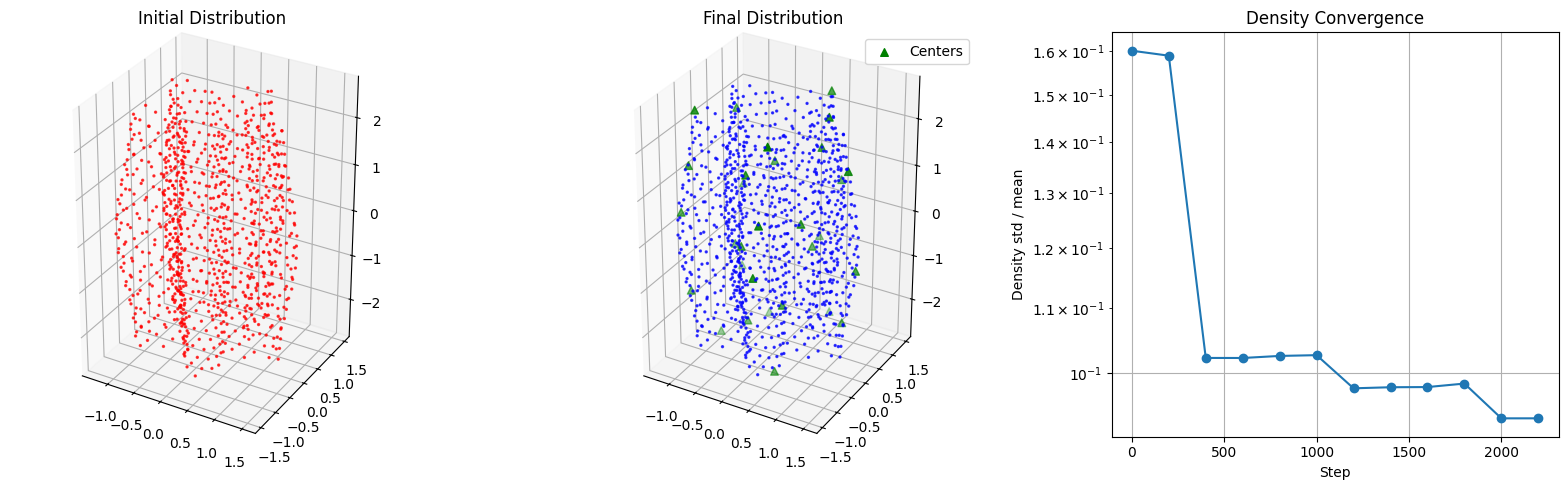

In [11]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 1000
MAX_DEG = 3
N_LOCAL = 30
EPSILON = 0.4
ALPHA = 2.0
DT = 0.01
MAX_STEPS = 2000
TOL = 1e-10
PROJECT_EVERY_STEP = True
K_NEIGHBORS = 20
MIN_SUPPORT = 10
SUPPORT_THRESHOLD = 1e-6
RESELECT_INTERVAL = 800

# 海星形曲面参数
NUM_ARMS = 5
ARM_AMPLITUDE = 0.4
Z_MIN, Z_MAX = -2.5, 2.5

def r_of_z_theta(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    return base_r * star_modulation

def r_and_dr(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    d_base_dz = -0.1 * np.pi / (Z_MAX - Z_MIN) * 2 * np.sin(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    d_star_dtheta = -ARM_AMPLITUDE * NUM_ARMS * np.sin(NUM_ARMS * theta)
    r = base_r * star_modulation
    dr_dz = d_base_dz * star_modulation
    dr_dtheta = base_r * d_star_dtheta
    return r, dr_dz, dr_dtheta

# ============================================
# 1. 海星曲面几何工具
# ============================================
def starfish_normal(X):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    r_xy = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    r, drdz, drdt = r_and_dr(z, theta)
    cos_t = x / (r_xy + 1e-15)
    sin_t = y / (r_xy + 1e-15)
    tx = drdz * cos_t
    ty = drdz * sin_t
    tz = np.ones_like(z)
    ux = drdt * cos_t - r * sin_t
    uy = drdt * sin_t + r * cos_t
    uz = np.zeros_like(z)
    nx = ty * uz - tz * uy
    ny = tz * ux - tx * uz
    nz = tx * uy - ty * ux
    normal = np.column_stack([nx, ny, nz])
    return normal / (np.linalg.norm(normal, axis=1, keepdims=True) + 1e-15)

def project_to_starfish(X, max_iter=30, tol=1e-12):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        r_current = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        r_target, _, _ = r_and_dr(z, theta)
        X_new = np.zeros_like(X)
        X_new[:, 0] = r_target * x / (r_current + 1e-15)
        X_new[:, 1] = r_target * y / (r_current + 1e-15)
        X_new[:, 2] = z
        X = X_new
    return X

def tangent_projection(v, X):
    normals = starfish_normal(X)
    return v - np.sum(v * normals, axis=1, keepdims=True) * normals

# ============================================
# 2. 生成初始点云
# ============================================
def fibonacci_starfish(n, concentration=0.2):
    indices = np.arange(n)
    z_uniform = Z_MIN + (Z_MAX - Z_MIN) * indices / n
    z_shifted = (z_uniform - Z_MIN) / (Z_MAX - Z_MIN)
    z_compressed = z_shifted ** concentration
    z = Z_MIN + z_compressed * (Z_MAX - Z_MIN)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    r, _, _ = r_and_dr(z, theta)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y, z])

# ============================================
# 3. 多项式基函数
# ============================================
def polynomial_basis_values(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                vals_list.append((x**i) * (y**j) * (z**k))
    return np.column_stack(vals_list)

def polynomial_basis_gradients(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    N_pts = len(X)
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    grads = np.zeros((N_pts, M_poly, 3))
    col = 0
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                if i > 0:
                    grads[:, col, 0] = i * (x**(i-1)) * (y**j) * (z**k)
                if j > 0:
                    grads[:, col, 1] = j * (x**i) * (y**(j-1)) * (z**k)
                if k > 0:
                    grads[:, col, 2] = k * (x**i) * (y**j) * (z**(k-1))
                col += 1
    return grads

# ============================================
# 4. Wendland C2 局部基函数
# ============================================
def wendland_c2(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = (1 - q[mask])**4 * (4 * q[mask] + 1)
    return result

def wendland_c2_grad(r, epsilon):
    q = epsilon * r
    result = np.zeros_like(q)
    mask = q <= 1.0
    result[mask] = -20 * epsilon * q[mask] * (1 - q[mask])**3
    return result

def local_basis_values(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    return wendland_c2(dist, epsilon)

def local_basis_gradients(X, centers, epsilon):
    diff = X[:, np.newaxis, :] - centers[np.newaxis, :, :]
    dist = np.linalg.norm(diff, axis=2)
    dist_safe = np.where(dist < 1e-12, 1e-12, dist)
    dphi_dr = wendland_c2_grad(dist_safe, epsilon)
    grad = dphi_dr[:, :, np.newaxis] * diff / dist_safe[:, :, np.newaxis]
    return grad

# ============================================
# 5. 混合基函数
# ============================================
def mixed_basis_values(X, max_deg, local_centers, epsilon):
    poly_vals = polynomial_basis_values(X, max_deg)
    local_vals = local_basis_values(X, local_centers, epsilon)
    return np.column_stack([poly_vals, local_vals])

def mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon):
    normals = starfish_normal(X)
    poly_grads = polynomial_basis_gradients(X, max_deg)
    local_grads = local_basis_gradients(X, local_centers, epsilon)
    all_grads = np.concatenate([poly_grads, local_grads], axis=1)
    normal_proj = np.sum(all_grads * normals[:, np.newaxis, :], axis=2)
    return all_grads - normal_proj[:, :, np.newaxis] * normals[:, np.newaxis, :]

# ============================================
# 6. 生成均匀点
# ============================================
def generate_uniform_points(n):
    z_vals = np.linspace(Z_MIN, Z_MAX, 1000)
    theta_sample = np.linspace(0, 2*np.pi, 500)
    ZZ, TT = np.meshgrid(z_vals, theta_sample, indexing='ij')
    r_grid, drdz_grid, drdt_grid = r_and_dr(ZZ, TT)
    area_element = r_grid * np.sqrt(r_grid**2 + drdt_grid**2 + r_grid**2 * drdz_grid**2)
    marginal_area = np.sum(area_element, axis=1) * (2*np.pi / 500)
    cdf = np.cumsum(marginal_area)
    cdf = cdf / cdf[-1]
    z_sampled = np.interp(np.random.rand(n), cdf, z_vals)
    theta_sampled = np.zeros(n)
    for i in range(n):
        z_idx = np.searchsorted(z_vals, z_sampled[i])
        if z_idx >= len(z_vals): z_idx = len(z_vals) - 1
        theta_dist = r_grid[z_idx, :] * np.sqrt(r_grid[z_idx, :]**2 + drdt_grid[z_idx, :]**2 + r_grid[z_idx, :]**2 * drdz_grid[z_idx, :]**2)
        theta_cdf = np.cumsum(theta_dist)
        theta_cdf = theta_cdf / theta_cdf[-1]
        theta_sampled[i] = np.interp(np.random.rand(), theta_cdf, theta_sample)
    r_sampled, _, _ = r_and_dr(z_sampled, theta_sampled)
    x = r_sampled * np.cos(theta_sampled)
    y = r_sampled * np.sin(theta_sampled)
    return np.column_stack([x, y, z_sampled])

def generate_uniform_centers(n_centers):
    candidates = generate_uniform_points(5000)
    selected = [np.random.randint(len(candidates))]
    min_dist = np.full(len(candidates), np.inf)
    for _ in range(n_centers - 1):
        last = candidates[selected[-1]]
        dist_to_last = np.linalg.norm(candidates - last, axis=1)
        min_dist = np.minimum(min_dist, dist_to_last)
        next_idx = np.argmax(min_dist)
        selected.append(next_idx)
        min_dist[next_idx] = -1
    return candidates[np.array(selected)]

# ============================================
# 7. 均匀参考值
# ============================================
def compute_uniform_reference(max_deg, local_centers, epsilon, n_samples=20000):
    X_ref = generate_uniform_points(n_samples)
    
    areas = np.zeros(n_samples)
    for i in range(n_samples):
        diff = X_ref - X_ref[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, 21)[1:21]
        neighbors = X_ref[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        areas[i] = np.pi * np.mean(dist_to_centroid)**2
    
    psi_sample = mixed_basis_values(X_ref, max_deg, local_centers, epsilon)
    return np.average(psi_sample, weights=areas, axis=0)

# ============================================
# 8. 密度估计
# ============================================
def estimate_density_std(X, k_neighbors=K_NEIGHBORS):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================
# 9. 支撑修剪求解器
# ============================================
def solve_with_support_pruning(X, max_deg, local_centers, epsilon, uniform_avg, alpha,
                               min_support=5, support_threshold=1e-8):
    M_poly = sum(1 for deg in range(1, max_deg + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_local = len(local_centers)
    M_total = M_poly + M_local
    
    psi = mixed_basis_values(X, max_deg, local_centers, epsilon)
    support_counts = np.sum(np.abs(psi) > support_threshold, axis=0)
    
    poly_valid = np.ones(M_poly, dtype=bool)
    local_valid = support_counts[M_poly:] >= min_support
    valid_mask = np.concatenate([poly_valid, local_valid])
    
    psi_grad_full = mixed_basis_gradients_tangent(X, max_deg, local_centers, epsilon)
    psi_valid = psi[:, valid_mask]
    psi_grad_valid = psi_grad_full[:, valid_mask, :]
    
    A_valid = np.mean(psi_grad_valid @ psi_grad_valid.transpose(0, 2, 1), axis=0)
    b_valid = -alpha * (np.mean(psi_valid, axis=0) - uniform_avg[valid_mask])
    
    c_valid = np.linalg.solve(A_valid, b_valid)
    
    c = np.zeros(M_total)
    c[valid_mask] = c_valid
    
    vT = np.sum(psi_grad_full * c[np.newaxis, :, np.newaxis], axis=1)
    vT = tangent_projection(vT, X)
    
    return vT, c, valid_mask, support_counts

# ============================================
# 10. 主算法
# ============================================
def main():
    M_poly = sum(1 for deg in range(1, MAX_DEG + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    M_total = M_poly + N_LOCAL
    
    print("=" * 60)
    print("Starfish Uniformization - Mixed Basis")
    print(f"Polynomial: deg≤{MAX_DEG}, {M_poly} functions")
    print(f"Local: {N_LOCAL} Wendland C2, epsilon={EPSILON}")
    print(f"Total: {M_total} basis functions")
    print(f"Min support: {MIN_SUPPORT} pts")
    print(f"Reselect centers every: {RESELECT_INTERVAL} steps")
    print("=" * 60)
    
    X = fibonacci_starfish(N, concentration=1.0)
    X_initial = X.copy()
    
    density_std_initial = estimate_density_std(X)
    print(f"Initial density std/mean: {density_std_initial:.6f}")
    
    np.random.seed(42)
    centers = generate_uniform_centers(N_LOCAL)
    print(f"Generated {N_LOCAL} uniform centers on surface")
    
    print("Computing uniform reference values...")
    uniform_avg = compute_uniform_reference(MAX_DEG, centers, EPSILON, n_samples=20000)
    print("Done.\n")
    
    density_history = [density_std_initial]
    
    print("=" * 60)
    print("Main iteration (Euler Forward)")
    print("=" * 60)
    
    for step in range(MAX_STEPS):
        if step > 0 and step % RESELECT_INTERVAL == 0:
            print(f"\nStep {step}: Reselecting basis centers...")
            centers = generate_uniform_centers(N_LOCAL)
            uniform_avg = compute_uniform_reference(MAX_DEG, centers, EPSILON, n_samples=20000)
            print(f"  New centers generated, reference values recomputed")
        
        vT, c, valid_mask, support_counts = solve_with_support_pruning(
            X, MAX_DEG, centers, EPSILON, uniform_avg, ALPHA,
            min_support=MIN_SUPPORT,
            support_threshold=SUPPORT_THRESHOLD
        )
        
        v_norm = np.max(np.linalg.norm(vT, axis=1))
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        X = X + dt_effective * vT
        if PROJECT_EVERY_STEP:
            X = project_to_starfish(X)
        
        if step % 200 == 0:
            psi = mixed_basis_values(X, MAX_DEG, centers, EPSILON)
            b_full = -ALPHA * (np.mean(psi, axis=0) - uniform_avg)
            max_b = np.max(np.abs(b_full))
            
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            
            n_active = np.sum(valid_mask)
            n_local_active = np.sum(valid_mask[M_poly:])
            
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max|b| = {max_b:.6e}, v_max = {v_norm:.4f}, "
                  f"active basis = {n_active}/{M_total} (local={n_local_active}/{N_LOCAL})")
        
        if v_norm < 1e-15:
            print(f"\nVelocity converged at step {step}")
            break
    
    density_std_final = estimate_density_std(X)
    density_history.append(density_std_final)
    print(f"\nFinal density std/mean: {density_std_final:.6f}")
    
    # 可视化
    fig = plt.figure(figsize=(16, 5))
    
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=2, c='red', alpha=0.7)
    ax1.set_title('Initial Distribution')
    ax1.set_box_aspect([1, 1, 1.5])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax2.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=30, c='green', marker='^', label='Centers')
    ax2.set_title('Final Distribution')
    ax2.set_box_aspect([1, 1, 1.5])
    ax2.legend()
    
    ax3 = fig.add_subplot(133)
    ax3.semilogy(np.arange(0, len(density_history)) * 200, density_history, 'o-')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Density std / mean')
    ax3.set_title('Density Convergence')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return X, density_history

if __name__ == "__main__":
    X_final, density_hist = main()

In [ ]:
import numpy as np
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# ============================================
# 0. 全局参数
# ============================================
N = 2000
MAX_DEG = 3           # 多项式最高次数
ALPHA = 2.0
DT = 0.01
MAX_STEPS = 1500
TOL = 1e-10
PROJECT_EVERY_STEP = True
K_NEIGHBORS = 20

# 海星形曲面参数
NUM_ARMS = 5
ARM_AMPLITUDE = 0.4
Z_MIN, Z_MAX = -2.5, 2.5

def r_of_z_theta(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    return base_r * star_modulation

def r_and_dr(z, theta):
    base_r = 1.0 + 0.1 * np.cos(np.pi * z / (Z_MAX - Z_MIN) * 2)
    d_base_dz = -0.1 * np.pi / (Z_MAX - Z_MIN) * 2 * np.sin(np.pi * z / (Z_MAX - Z_MIN) * 2)
    star_modulation = 1.0 + ARM_AMPLITUDE * np.cos(NUM_ARMS * theta)
    d_star_dtheta = -ARM_AMPLITUDE * NUM_ARMS * np.sin(NUM_ARMS * theta)
    r = base_r * star_modulation
    dr_dz = d_base_dz * star_modulation
    dr_dtheta = base_r * d_star_dtheta
    return r, dr_dz, dr_dtheta

# ============================================
# 1. 海星曲面几何工具
# ============================================
def starfish_normal(X):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    r_xy = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    r, drdz, drdt = r_and_dr(z, theta)
    cos_t = x / (r_xy + 1e-15)
    sin_t = y / (r_xy + 1e-15)
    tx = drdz * cos_t
    ty = drdz * sin_t
    tz = np.ones_like(z)
    ux = drdt * cos_t - r * sin_t
    uy = drdt * sin_t + r * cos_t
    uz = np.zeros_like(z)
    nx = ty * uz - tz * uy
    ny = tz * ux - tx * uz
    nz = tx * uy - ty * ux
    return np.column_stack([nx, ny, nz])

def project_to_starfish(X, max_iter=30, tol=1e-12):
    for _ in range(max_iter):
        x, y, z = X[:, 0], X[:, 1], X[:, 2]
        r_current = np.sqrt(x**2 + y**2)
        theta = np.arctan2(y, x)
        r_target, _, _ = r_and_dr(z, theta)
        f = r_current - r_target
        X_new = np.zeros_like(X)
        X_new[:, 0] = r_target * x / (r_current + 1e-15)
        X_new[:, 1] = r_target * y / (r_current + 1e-15)
        X_new[:, 2] = z
        X = X_new
        if np.max(np.abs(f)) < tol:
            break
    return X

def starfish_tangent_projection(v, X):
    normal = starfish_normal(X)
    normal = normal / (np.linalg.norm(normal, axis=1, keepdims=True) + 1e-15)
    return v - np.sum(v * normal, axis=1, keepdims=True) * normal

# ============================================
# 2. 生成初始集中点云
# ============================================
def fibonacci_starfish(n, concentration=0.2):
    indices = np.arange(n)
    z_uniform = Z_MIN + (Z_MAX - Z_MIN) * indices / n
    z_shifted = (z_uniform - Z_MIN) / (Z_MAX - Z_MIN)
    z_compressed = z_shifted ** concentration
    z = Z_MIN + z_compressed * (Z_MAX - Z_MIN)
    theta = np.pi * (1 + np.sqrt(5)) * indices
    r, _, _ = r_and_dr(z, theta)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y, z])

# ============================================
# 3. 多项式基函数（次数 ≤ MAX_DEG，不含常数项）
# ============================================
def polynomial_basis(X, max_deg):
    x, y, z = X[:, 0], X[:, 1], X[:, 2]
    vals_list = []
    grads_list = []
    for deg in range(1, max_deg + 1):
        for i in range(deg + 1):
            for j in range(deg + 1 - i):
                k = deg - i - j
                v = (x**i) * (y**j) * (z**k)
                vals_list.append(v)
                gx = np.zeros(len(X)) if i == 0 else i * (x**(i-1)) * (y**j) * (z**k)
                gy = np.zeros(len(X)) if j == 0 else j * (x**i) * (y**(j-1)) * (z**k)
                gz = np.zeros(len(X)) if k == 0 else k * (x**i) * (y**j) * (z**(k-1))
                g = np.column_stack([gx, gy, gz])
                g_tangent = starfish_tangent_projection(g, X)
                grads_list.append(g_tangent)
    vals = np.column_stack(vals_list)
    grads = np.stack(grads_list, axis=1)
    return vals, grads

# ============================================
# 4. 密度估计
# ============================================
def estimate_density_std(X, k_neighbors=K_NEIGHBORS):
    N_pts = len(X)
    local_density = np.zeros(N_pts)
    for i in range(N_pts):
        diff = X - X[i]
        dist = np.linalg.norm(diff, axis=1)
        idx = np.argpartition(dist, k_neighbors+1)[1:k_neighbors+1]
        neighbors = X[idx]
        centroid = np.mean(neighbors, axis=0)
        dist_to_centroid = np.linalg.norm(neighbors - centroid, axis=1)
        local_area = np.pi * np.mean(dist_to_centroid)**2
        local_density[i] = k_neighbors / (local_area + 1e-12)
    return np.std(local_density) / np.mean(local_density)

# ============================================
# 5. 计算均匀测度下的基函数平均值
# ============================================
def compute_uniform_averages_starfish(max_deg, n_samples=50000):
    z_vals = np.linspace(Z_MIN, Z_MAX, 1000)
    theta_sample = np.linspace(0, 2*np.pi, 500)
    ZZ, TT = np.meshgrid(z_vals, theta_sample, indexing='ij')
    r_grid, drdz_grid, drdt_grid = r_and_dr(ZZ, TT)
    area_element = r_grid * np.sqrt(r_grid**2 + drdt_grid**2 + r_grid**2 * drdz_grid**2)
    marginal_area = np.sum(area_element, axis=1) * (2*np.pi / 500)
    cdf = np.cumsum(marginal_area)
    cdf = cdf / cdf[-1]
    z_sampled = np.interp(np.random.rand(n_samples), cdf, z_vals)
    theta_sampled = np.zeros(n_samples)
    for i in range(n_samples):
        z_idx = np.searchsorted(z_vals, z_sampled[i])
        if z_idx >= len(z_vals): z_idx = len(z_vals) - 1
        theta_dist = r_grid[z_idx, :] * np.sqrt(r_grid[z_idx, :]**2 + drdt_grid[z_idx, :]**2 + r_grid[z_idx, :]**2 * drdz_grid[z_idx, :]**2)
        theta_cdf = np.cumsum(theta_dist)
        theta_cdf = theta_cdf / theta_cdf[-1]
        theta_sampled[i] = np.interp(np.random.rand(), theta_cdf, theta_sample)
    r_sampled, _, _ = r_and_dr(z_sampled, theta_sampled)
    x = r_sampled * np.cos(theta_sampled)
    y = r_sampled * np.sin(theta_sampled)
    X_sample = np.column_stack([x, y, z_sampled])
    vals, _ = polynomial_basis(X_sample, max_deg)
    return np.mean(vals, axis=0)

def estimate_starfish_area(n_samples=50000):
    z_vals = np.linspace(Z_MIN, Z_MAX, 1000)
    theta_sample = np.linspace(0, 2*np.pi, 500)
    ZZ, TT = np.meshgrid(z_vals, theta_sample, indexing='ij')
    r_grid, drdz_grid, drdt_grid = r_and_dr(ZZ, TT)
    area_element = r_grid * np.sqrt(r_grid**2 + drdt_grid**2 + r_grid**2 * drdz_grid**2)
    dz = (Z_MAX - Z_MIN) / 1000
    dtheta = 2 * np.pi / 500
    return np.sum(area_element) * dz * dtheta

# ============================================
# 6. 主算法
# ============================================
def main():
    print("=" * 60)
    print("Step 0: Preparation")
    print("=" * 60)
    
    X = fibonacci_starfish(N, concentration=0.2)
    X_initial = X.copy()
    
    M = sum(1 for deg in range(1, MAX_DEG + 1) for i in range(deg + 1) for j in range(deg + 1 - i))
    print(f"Max degree: {MAX_DEG}, Total basis functions: {M}")
    print(f"Initial density std/mean: {estimate_density_std(X):.6f}")
    
    print("Estimating surface area...")
    total_area = estimate_starfish_area()
    print(f"  Estimated area: {total_area:.4f}")
    
    print("Computing uniform averages...")
    uniform_avg = compute_uniform_averages_starfish(MAX_DEG)
    print("  Done.")
    
    print("=" * 60)
    print("Main iteration")
    print("=" * 60)
    
    residual_history = []
    density_history = [estimate_density_std(X)]
    
    for step in range(MAX_STEPS):
        vals, grads = polynomial_basis(X, MAX_DEG)
        
        A = np.zeros((M, M))
        b = np.zeros(M)
        for m in range(M):
            b[m] = -ALPHA * (np.mean(vals[:, m]) - uniform_avg[m])
            for k in range(M):
                A[m, k] = np.mean(np.sum(grads[:, k, :] * grads[:, m, :], axis=1))
        
        try:
            c = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            c = np.linalg.lstsq(A, b, rcond=None)[0]
        
        v = np.zeros_like(X)
        for k in range(M):
            v += c[k] * grads[:, k, :]
        v = starfish_tangent_projection(v, X)
        
        v_norm = np.max(np.linalg.norm(v, axis=1))
        dt_effective = min(DT, 0.01 / (v_norm + 1e-8))
        
        def compute_velocity(X_pts):
            _, grads_t = polynomial_basis(X_pts, MAX_DEG)
            v_t = np.zeros_like(X_pts)
            for k in range(M):
                v_t += c[k] * grads_t[:, k, :]
            return starfish_tangent_projection(v_t, X_pts)
        
        k1 = compute_velocity(X)
        k2 = compute_velocity(X + 0.5 * dt_effective * k1)
        k3 = compute_velocity(X + 0.5 * dt_effective * k2)
        k4 = compute_velocity(X + dt_effective * k3)
        
        X_new = X + (dt_effective / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        if PROJECT_EVERY_STEP:
            X_new = project_to_starfish(X_new)
        X = X_new
        
        max_residual = np.max(np.abs(b)) / ALPHA
        residual_history.append(max_residual)
        
        if step % 200 == 0:
            density_std = estimate_density_std(X)
            density_history.append(density_std)
            print(f"Step {step}: density std/mean = {density_std:.6f}, "
                  f"max residual = {max_residual:.6e}, dt = {dt_effective:.6f}, v_max = {v_norm:.4f}")
        
        if max_residual < TOL:
            print(f"Converged at step {step}")
            break
    
    density_std_final = estimate_density_std(X)
    density_history.append(density_std_final)
    print(f"Final density std/mean: {density_std_final:.6f}")
    
    # 可视化
    fig = plt.figure(figsize=(16, 5))
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(X_initial[:, 0], X_initial[:, 1], X_initial[:, 2], s=2, c='red', alpha=0.7)
    ax1.set_title('Initial Distribution')
    ax1.set_box_aspect([1, 1, 1.5])
    
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(X[:, 0], X[:, 1], X[:, 2], s=2, c='blue', alpha=0.7)
    ax2.set_title(f'Final Distribution ({len(density_history)*200} steps)')
    ax2.set_box_aspect([1, 1, 1.5])
    
    ax3 = fig.add_subplot(133)
    ax3.semilogy(np.arange(0, len(density_history)) * 200, density_history, 'o-')
    ax3.set_xlabel('Step')
    ax3.set_ylabel('Density std / mean')
    ax3.set_title('Density Convergence')
    ax3.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return X, residual_history, density_history

if __name__ == "__main__":
    X_final, history, density_hist = main()